In [27]:
%matplotlib widget

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
columns = [
    "shoe_hand_idx",
    "dealer_hand",
    "player_hand_0",
    "player_hand_1",
    "total_bet",
    "net_value",
    "true_count",
    "remaining_cards",
    "datetime"
]

In [3]:
result_tables = list(sorted(glob.glob("logs/play_*.csv")))

In [4]:
result_tables

['logs/play_2025_11_15_15_52_38.csv',
 'logs/play_2025_11_15_15_56_25.csv',
 'logs/play_2025_11_15_15_57_30.csv',
 'logs/play_2025_11_15_16_50_09.csv',
 'logs/play_2025_11_15_17_00_13.csv',
 'logs/play_2025_11_15_17_06_55.csv',
 'logs/play_2025_11_15_17_10_05.csv',
 'logs/play_2025_11_15_17_22_40.csv',
 'logs/play_2025_11_15_17_32_30.csv',
 'logs/play_2025_11_15_17_43_02.csv',
 'logs/play_2025_11_15_17_51_37.csv',
 'logs/play_2025_11_15_18_27_08.csv',
 'logs/play_2025_11_15_19_14_29.csv',
 'logs/play_2025_11_15_19_23_25.csv',
 'logs/play_2025_11_15_19_53_58.csv',
 'logs/play_2025_11_15_19_58_17.csv',
 'logs/play_2025_11_15_20_11_04.csv',
 'logs/play_2025_11_15_20_20_50.csv',
 'logs/play_2025_11_15_20_21_16.csv',
 'logs/play_2025_11_16_17_30_02.csv',
 'logs/play_2025_11_16_17_30_58.csv',
 'logs/play_2025_11_16_17_57_13.csv',
 'logs/play_2025_11_16_18_14_31.csv',
 'logs/play_2025_11_16_18_14_57.csv',
 'logs/play_2025_11_16_19_14_15.csv',
 'logs/play_2025_11_16_19_40_47.csv',
 'logs/play_

In [5]:
table = pd.read_csv(result_tables[0])

In [6]:
table["net_value"]

0   -500
1      0
2   -500
3   -250
4      0
5    250
Name: net_value, dtype: int64

In [7]:
tables = [pd.read_csv(t) for t in result_tables]
tables = [t for t in tables if len(t) > 0]

In [8]:
main_table = pd.concat(tables)

In [9]:
cum_value = np.cumsum(main_table["net_value"].values)
cum_value = np.r_[0, cum_value]

In [10]:
# ev_per_hand_units = 0.008
# sd_per_hand_units = 3.5
ev_per_hand_units = 42.312833884831015 / 1000
sd_per_hand_units = 7167.133282047346 / 1000
unit = 250

mu = ev_per_hand_units * unit
sigma = sd_per_hand_units * unit
hand_idx = np.arange(len(cum_value))
ev = mu * hand_idx
sd = np.sqrt(hand_idx) * sigma

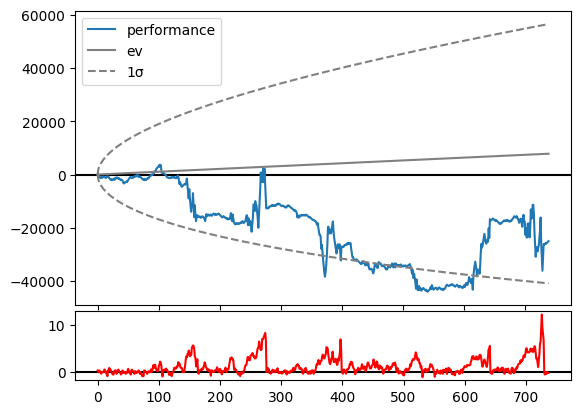

In [26]:
import matplotlib.gridspec as gridspec

fig = plt.figure()
gs = gridspec.GridSpec(10, 1, figure=fig)


ax = fig.add_subplot(gs[:-2, :])
ax2 = fig.add_subplot(gs[-2:, :])
ax.axhline(0, color="black")
ax2.axhline(0, color="black")

main_table["true_count"]

ax.plot(cum_value, label="performance")
ax.plot(ev, color="gray", label="ev")
ax.plot(ev + sd, color="grey", ls="--", label="1σ")
ax.plot(ev - sd, color="gray", ls="--")

ax2.plot(main_table["true_count"].values, color="red")

ax.legend()

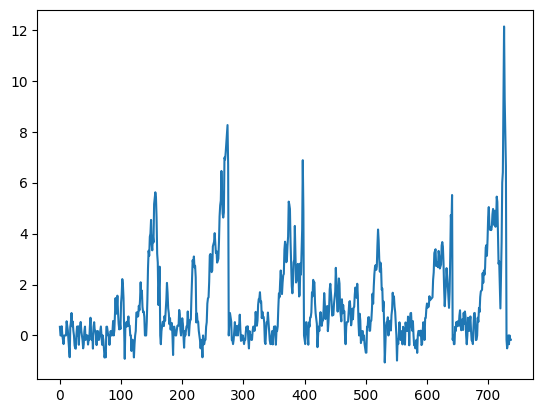